# FatigueSet Library — Guía Completa
### Procesado de datos multimodal de fatiga física y mental

Este notebook documenta la librería `fatigueset` y replica el pipeline completo del notebook
**FatigueSet Procesado de datos.ipynb**, sustituyendo el código inline por las clases y funciones
de la librería.

---

## Arquitectura de la librería

```
fatigueset/
├── loader.py      → Carga de CSV del dataset (DataLoader, FatigueSetLoader)
├── processor.py   → Procesado de señales y construcción del dataset ML
├── features.py    → Extracción avanzada de features estadísticas
├── validators.py  → Validación de integridad de datos
├── utils.py       → Visualizaciones con matplotlib/seaborn
└── __init__.py    → API pública
```

**Protocolo por sesión:**  
S1 (baseline) → **M1** (VAS+CRT+Nback) → S2 (ejercicio físico) → **M2** (VAS+CRT+Nback) → S3 (task switching ~15min) → **M3** (VAS+CRT+Nback)

**Sensores:**  
Zephyr BioHarness (ECG/HR/HRV/BR) · Empatica E4 (EDA/BVP/Temp) · Muse EEG (α/β/δ/γ/θ) · Nokia eSense (PPG auricular)

**Dataset:** 12 participantes × 3 sesiones (low/medium/high intensity) × 3 fases de medición = **108 observaciones**

---
## Celda 1 — Instalación e importaciones

In [1]:
import sys
from pathlib import Path

# Resolver rutas aunque el notebook esté en Jupyters/
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'fatigueset-lib').exists() and (p / 'fatigueset').exists()), Path.cwd())
LIB_PATH = (PROJECT_ROOT / 'fatigueset-lib').resolve()
if str(LIB_PATH) not in sys.path:
    sys.path.insert(0, str(LIB_PATH))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

# Importar la librería completa
from fatigueset import (
    FatigueSetLoader,
    FatigueSetProcessor,
    FatigueSetValidator,
    FeatureExtractor,
    utils,
    PARTICIPANTES,
    SESIONES,
    FASES_MEDICION,
    CANALES_EEG,
)

# Ruta al dataset resuelta desde la raíz del proyecto
BASE_PATH = PROJECT_ROOT / 'fatigueset'

print('✓ Librería fatigueset importada correctamente')
print(f'  Ruta librería: {LIB_PATH.resolve()}')
print(f'  Ruta dataset:  {BASE_PATH.resolve()}')
print(f'  Dataset existe: {BASE_PATH.exists()}')
print(f'  Participantes: {PARTICIPANTES}')
print(f'  Sesiones: {SESIONES}')
print(f'  Fases: {FASES_MEDICION}')
print(f'  Canales EEG: {CANALES_EEG}')

✓ Librería fatigueset importada correctamente
  Ruta librería: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset-lib
  Ruta dataset:  C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset
  Dataset existe: True
  Participantes: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
  Sesiones: ['01', '02', '03']
  Fases: {0: 'M1_baseline', 1: 'M2_post_ejercicio', 2: 'M3_post_fatiga_mental'}
  Canales EEG: ['TP9', 'AF7', 'AF8', 'TP10']


---
## Celda 2 — `DataLoader`: carga genérica de CSV

La clase `DataLoader` es la base de la jerarquía. Proporciona:
- `load_csv(path)` → carga un archivo `.csv` individual
- `load_all(dir_path)` → carga todos los `.csv` de un directorio

No depende de la estructura del dataset FatigueSet; sirve para cualquier CSV.

In [2]:
from fatigueset.loader import DataLoader

# DataLoader genérico: base_path apunta al directorio de trabajo actual
# Las rutas pasadas a load_csv son relativas a ese base_path
loader = DataLoader(base_path='.')

# Cargar un archivo individual usando la ruta completa desde el directorio actual
ruta_ejemplo = BASE_PATH / '01' / '01' / 'exp_fatigue.csv'

if ruta_ejemplo.exists():
    df_ejemplo = loader.load_csv(ruta_ejemplo)
    print(f'✓ Archivo cargado: {ruta_ejemplo}')
    print(f'  Shape: {df_ejemplo.shape}')
    print(f'  Columnas: {list(df_ejemplo.columns)}')
    display(df_ejemplo.head())
else:
    print(f'⚠ Archivo no encontrado: {ruta_ejemplo.resolve()}')
    print('  Ajusta BASE_PATH para apuntar a la carpeta raíz del dataset.')

✓ Archivo cargado: c:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset\01\01\exp_fatigue.csv
  Shape: (3, 6)
  Columnas: ['measurementNumber', 'physicalFatigueAnswerTime', 'mentalFatigueAnswerTime', 'fatigueSurveySubmissionTime', 'physicalFatigueScore', 'mentalFatigueScore']


,measurementNumber,physicalFatigueAnswerTime,mentalFatigueAnswerTime,fatigueSurveySubmissionTime,physicalFatigueScore,mentalFatigueScore
0,0,226.380555,234.136118,238.965037,14.444444,14.166667
1,1,686.570569,690.081112,694.569383,24.027778,11.250000
2,2,1462.908608,1464.458902,1467.546922,20.000000,45.833333


---
## Celda 3 — `FatigueSetLoader`: carga estructurada del dataset

`FatigueSetLoader` es el loader principal. Conoce la estructura de carpetas
`fatigueset/<participante>/<sesion>/<archivo.csv>` y gestiona automáticamente:

- El mapeo de intensidades desde `metadata.csv`
- La adición de columnas `participante`, `sesion`, `intensidad`, `intensidad_num`
- La concatenación de todos los participantes en un solo DataFrame

In [3]:
# Crear el loader apuntando a la carpeta raíz del dataset
fs_loader = FatigueSetLoader(base_path=BASE_PATH)

# Paso 1: Construir el mapa de intensidades desde metadata.csv
# metadata.csv tiene columnas: participant_id, low_session, medium_session, high_session
# La librería invierte: {pid: {sesion: 'low'|'medium'|'high'}}
intensidad_map = fs_loader.construir_intensidad_map()

print('✓ Mapa de intensidades construido para', len(intensidad_map), 'participantes')
print('\nEjemplos:')
for pid in ['01', '02', '08']:
    print(f'  P{pid}: {intensidad_map.get(pid)}')

✓ Mapa de intensidades construido para 12 participantes

Ejemplos:
  P01: {'01': 'low', '02': 'medium', '03': 'high'}
  P02: {'01': 'low', '03': 'medium', '02': 'high'}
  P08: {'01': 'low', '03': 'medium', '02': 'high'}


In [4]:
# Cargar todo el dataset de una vez
# cargar_todo() devuelve un dict con todas las señales concatenadas
dataset = fs_loader.cargar_todo(verbose=True)

# Acceder a cada señal
df_fatiga     = dataset['fatiga']
df_markers    = dataset['markers']
df_chest      = dataset['chest']
df_wrist_eda  = dataset['wrist']['eda']
df_wrist_hr   = dataset['wrist']['hr']
eeg_data      = dataset['eeg']     # dict {banda: DataFrame}
df_nback      = dataset['nback']
df_crt        = dataset['crt']

print('\nResumen de datos cargados:')
for nombre, obj in [
    ('fatiga', df_fatiga), ('markers', df_markers), ('chest', df_chest),
    ('wrist_eda', df_wrist_eda), ('nback', df_nback), ('crt', df_crt)
]:
    if obj is not None:
        print(f'  {nombre:12s}: {len(obj):>6} filas | {obj["participante"].nunique()} participantes')

Cargando dataset FatigueSet completo...



📋 Dataset cargado:
   Participantes: 12
   Sesiones:      36
   exp_fatigue:   108 registros
   chest:         45874 registros
   wrist_hr:  43608 registros
   wrist_eda:  174423 registros
   wrist_bvp:  2790818 registros
   wrist_temp:  174161 registros
   wrist_acc:  1395411 registros
   wrist_ibi:  23495 registros
   eeg_alpha:    413176 registros
   eeg_beta:    413130 registros
   eeg_delta:    413058 registros
   eeg_gamma:    412833 registros
   eeg_theta:    413029 registros

Resumen de datos cargados:
  fatiga      :    108 filas | 12 participantes
  markers     :    612 filas | 12 participantes
  chest       :  45874 filas | 12 participantes
  wrist_eda   : 174423 filas | 12 participantes
  nback       :   2160 filas | 12 participantes
  crt         :   3888 filas | 12 participantes


---
## Celda 4 — `FatigueSetValidator`: validación de integridad

Antes de procesar datos es importante verificar:
- Que los archivos críticos existen para todos los participantes/sesiones
- Que el porcentaje de nulos es aceptable (umbral por defecto: 5%)
- Que no hay filas duplicadas inesperadas

In [5]:
from fatigueset import FatigueSetValidator

validator = FatigueSetValidator(loader=fs_loader, umbral_nulos=5.0)

# Validar todos los archivos críticos para todos los participantes y sesiones
validator.imprimir_resumen()


VALIDACIÓN DE INTEGRIDAD DE DATOS

📊 Resumen por tipo de archivo (umbral nulos: 5.0%):
                  Sesiones_OK  Sesiones_total  Nulos_pct_max  Duplicados_max
Archivo                                                                     
CRT Task                   36              36           0.62               0
Chest Physiology           36              36           3.71               0
ECG Raw                    36              36           0.00               0
EEG Alpha                  22              36           0.00             782
EEG Beta                   23              36           0.00             781
Ear PPG Left               36              36           0.00               0
Fatigue Scores             36              36           0.00               0
N-Back Task                 0              36          28.52               0
Wrist EDA                  36              36           0.00               0
Wrist HR                   36              36           0.00      

In [6]:
# Acceder al DataFrame de validación para análisis
from fatigueset.validators import ARCHIVOS_CRITICOS

df_validacion = validator.validar_todos(
    archivos=ARCHIVOS_CRITICOS,
    participantes=PARTICIPANTES,
    sesiones=SESIONES
)

resumen_arch, df_problemas = validator.resumen(df_validacion)

print(f'Archivos críticos validados: {len(resumen_arch)}')
print(f'Registros con problemas: {len(df_problemas)}')
display(resumen_arch)

Archivos críticos validados: 11
Registros con problemas: 63


,Sesiones_OK,Sesiones_total,Nulos_pct_max,Duplicados_max
Archivo,,,,
CRT Task,36,36,0.62,0
Chest Physiology,36,36,3.71,0
ECG Raw,36,36,0.00,0
EEG Alpha,22,36,0.00,782
EEG Beta,23,36,0.00,781
Ear PPG Left,36,36,0.00,0
Fatigue Scores,36,36,0.00,0
N-Back Task,0,36,28.52,0
Wrist EDA,36,36,0.00,0


---
## Celda 5 — Explorar datos de fatiga (VAS)

`exp_fatigue.csv` contiene las puntuaciones VAS (Visual Analogue Scale 0-100)
de fatiga física y mental en cada momento de medición M1, M2, M3.

In [7]:
if df_fatiga is not None:
    print(f'Shape: {df_fatiga.shape}')
    print(f'Columnas: {list(df_fatiga.columns)}')
    print()
    print('Estadísticas por intensidad y fase:')
    display(
        df_fatiga.groupby(['intensidad', 'fase'])[
            ['physicalFatigueScore', 'mentalFatigueScore']
        ].describe().round(2)
    )

Shape: (108, 11)
Columnas: ['measurementNumber', 'physicalFatigueAnswerTime', 'mentalFatigueAnswerTime', 'fatigueSurveySubmissionTime', 'physicalFatigueScore', 'mentalFatigueScore', 'participante', 'sesion', 'intensidad', 'intensidad_num', 'fase']

Estadísticas por intensidad y fase:


physicalFatigueScore                       \
                                                count   mean    std    min   
intensidad fase                                                              
high       M1_baseline                           12.0  13.58  12.17   0.28   
           M2_post_ejercicio                     12.0  45.22  21.43  15.28   
           M3_post_fatiga_mental                 12.0  29.36  16.04   0.97   
low        M1_baseline                           12.0  12.91  14.71   0.00   
           M2_post_ejercicio                     12.0  18.87  17.22   0.00   
           M3_post_fatiga_mental                 12.0  22.15  18.31   0.00   
medium     M1_baseline                           12.0  16.31  15.40   0.00   
           M2_post_ejercicio                     12.0  29.37  18.56   0.00   
           M3_post_fatiga_mental                 12.0  23.99  15.66   0.00   

                                                              \
                                    25%    50%    75%    max   
intensidad fase                                                
high       M1_baseline             4.83  10.28  18.09  41.25   
           M2_post_ejercicio      27.95  43.40  61.77  77.22   
           M3_post_fatiga_mental  21.81  25.62  42.67  56.11   
low        M1_baseline             1.18   9.31  19.58  50.28   
           M2_post_ejercicio       7.99  14.03  26.46  55.28   
           M3_post_fatiga_mental  10.00  15.90  31.42  57.78   
medium     M1_baseline             8.68  13.33  17.05  55.42   
           M2_post_ejercicio      19.34  26.60  42.47  59.17   
           M3_post_fatiga_mental  13.82  24.93  33.06  46.53   

                                 mentalFatigueScore                      \
                                              count   mean    std   min   
intensidad fase                                                           
high       M1_baseline                         12.0  15.97  15.70  0.00   
           M2_post_ejercicio                   12.0  26.49  18.95  0.14   
           M3_post_fatiga_mental               12.0  37.74  23.58  0.28   
low        M1_baseline                         12.0  15.00  12.20  0.14   
           M2_post_ejercicio                   12.0  19.49  15.58  0.28   
           M3_post_fatiga_mental               12.0  35.25  22.92  0.00   
medium     M1_baseline                         12.0  24.11  17.70  0.00   
           M2_post_ejercicio                   12.0  27.49  18.57  0.42   
           M3_post_fatiga_mental               12.0  36.15  20.86  0.00   

                                                              
                                    25%    50%    75%    max  
intensidad fase                                               
high       M1_baseline             4.65  11.25  20.24  52.22  
           M2_post_ejercicio      13.47  21.11  37.71  57.92  
           M3_post_fatiga_mental  24.76  32.29  45.28  77.22  
low        M1_baseline             3.61  13.89  21.56  35.00  
           M2_post_ejercicio       4.97  20.90  30.56  47.08  
           M3_post_fatiga_mental  19.10  30.97  51.22  74.44  
medium     M1_baseline            14.13  22.36  33.16  67.78  
           M2_post_ejercicio      16.63  28.96  37.19  62.50  
           M3_post_fatiga_mental  21.77  34.58  48.16  74.31

---
## Celda 6 — Visualizar evolución de fatiga → `utils.plot_fatiga_evolucion()`

Muestra la trayectoria M1→M2→M3 para cada sesión (líneas transparentes)
y la media por grupo de intensidad (línea gruesa).

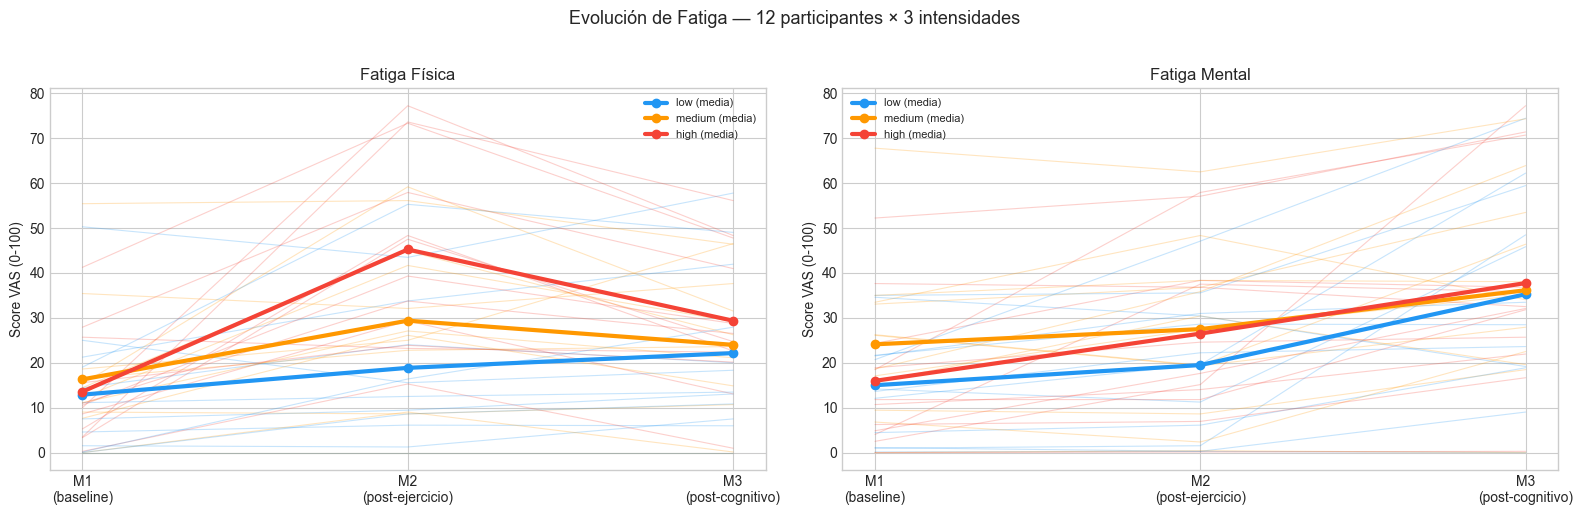

In [8]:
if df_fatiga is not None:
    fig = utils.plot_fatiga_evolucion(df_fatiga)
    plt.show()

---
## Celda 7 — `FatigueSetProcessor.calcular_fatigabilidad()`

Calcula los **deltas entre fases** para cuantificar cuánto aumenta la fatiga:

| Delta | Interpretación |
|---|---|
| `delta_fisica_ejercicio` | M2 − M1: efecto del ejercicio sobre fatiga física |
| `delta_mental_ejercicio` | M2 − M1: efecto del ejercicio sobre fatiga mental |
| `delta_fisica_cognitivo` | M3 − M2: efecto del task-switching cognitivo |
| `delta_mental_cognitivo` | M3 − M2: efecto cognitivo sobre fatiga mental |
| `delta_fisica_total`     | M3 − M1: efecto total de la sesión |
| `delta_mental_total`     | M3 − M1: efecto total sobre fatiga mental |

In [9]:
# Crear el procesador con el mapa de intensidades
processor = FatigueSetProcessor(intensidad_map=intensidad_map)

if df_fatiga is not None:
    df_fatigabilidad = processor.calcular_fatigabilidad(df_fatiga)

    print(f'✓ Fatigabilidad: {len(df_fatigabilidad)} sesiones de {df_fatigabilidad["participante"].nunique()} participantes')
    print()
    print('Media por intensidad:')
    display(
        df_fatigabilidad.groupby('intensidad')[
            ['delta_fisica_ejercicio', 'delta_mental_ejercicio',
             'delta_fisica_cognitivo', 'delta_mental_cognitivo',
             'delta_fisica_total',     'delta_mental_total']
        ].mean().round(2)
    )

✓ Fatigabilidad: 36 sesiones de 12 participantes

Media por intensidad:


,delta_fisica_ejercicio,delta_mental_ejercicio,delta_fisica_cognitivo,delta_mental_cognitivo,delta_fisica_total,delta_mental_total
intensidad,,,,,,
high,31.64,10.52,-15.86,11.25,15.79,21.77
low,5.96,4.49,3.29,15.76,9.25,20.25
medium,13.07,3.38,-5.38,8.66,7.69,12.04


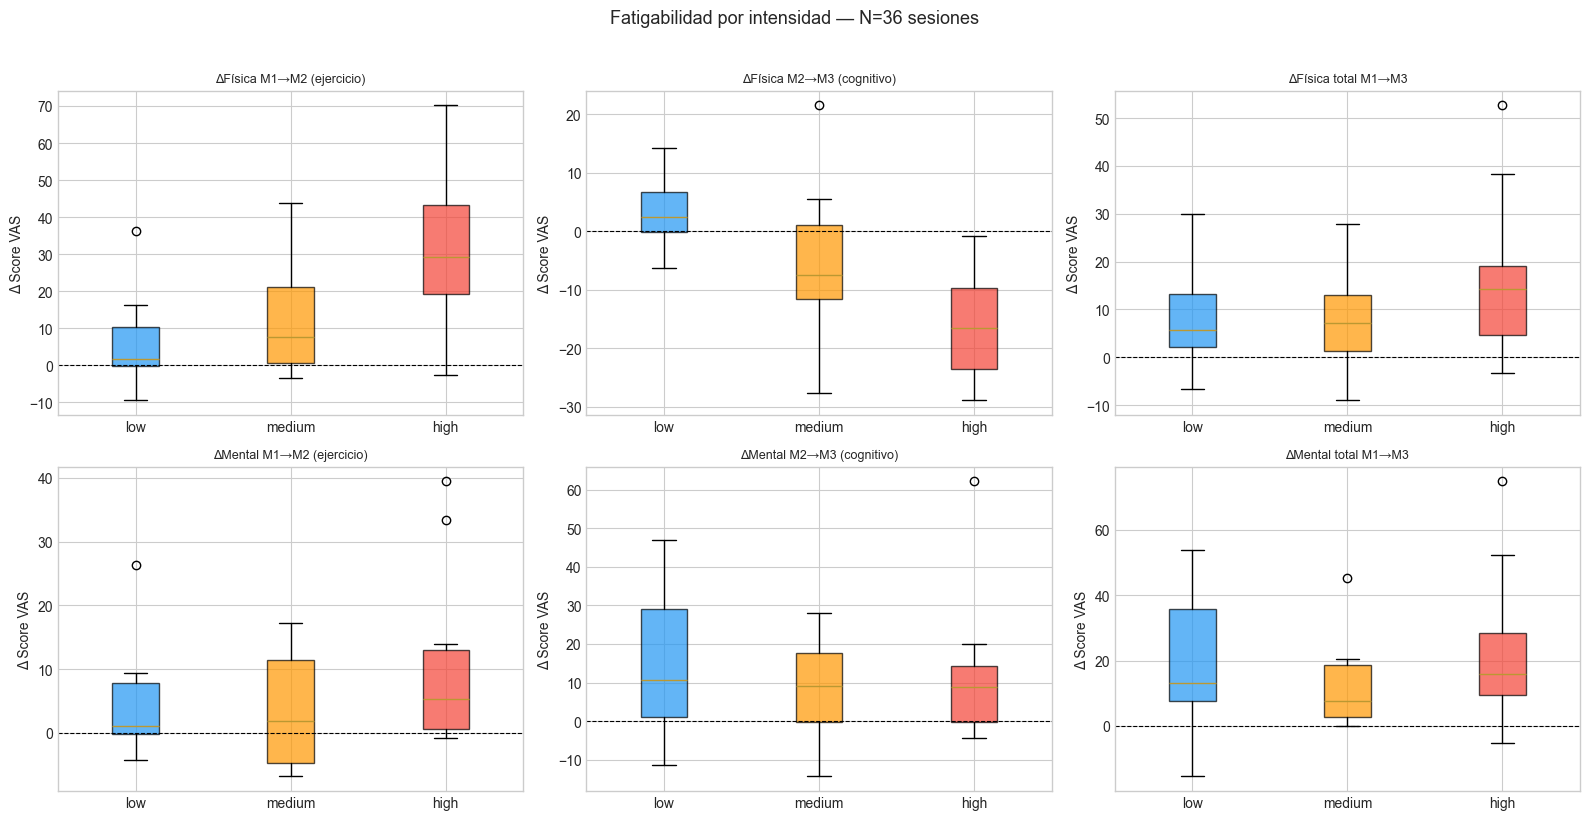

In [10]:
# Boxplots de fatigabilidad por intensidad
if df_fatiga is not None:
    fig = utils.plot_boxplots_fatigabilidad(df_fatigabilidad)
    plt.show()

---
## Celda 8 — Señales del pecho: Zephyr BioHarness

`chest_physiology_summary.csv` contiene frecuencia cardíaca (HR), frecuencia
respiratoria (BR) y variabilidad cardíaca (HRV) resumidas por ventana.

La librería convierte automáticamente el timestamp de milisegundos a `datetime`.

In [11]:
if df_chest is not None:
    print(f'Shape: {df_chest.shape}')
    print(f'Columnas: {list(df_chest.columns)}')
    print()

    cols_fisio = [c for c in ['hr', 'br', 'hrv', 'posture'] if c in df_chest.columns]
    print('Estadísticas por intensidad:')
    display(df_chest.groupby('intensidad')[cols_fisio].describe().round(2))

Shape: (45874, 14)
Columnas: ['timestamp', 'hr', 'br', 'posture', 'hr_confidence', 'hrv', 'is_hr_unreliable', 'is_br_unreliable', 'is_hrv_unreliable', 'participante', 'sesion', 'intensidad', 'intensidad_num', 'datetime']

Estadísticas por intensidad:


hr                                                     br  \
              count   mean    std   min   25%   50%    75%    max    count   
intensidad                                                                   
high        15461.0  98.32  30.13  52.0  75.0  91.0  116.0  211.0  15461.0   
low         14332.0  79.32  17.13  48.0  69.0  77.0   87.0  163.0  14332.0   
medium      16081.0  85.19  20.66  56.0  72.0  79.0   91.0  172.0  16081.0   

                                                           hrv                \
             mean   std   min   25%   50%   75%   max    count   mean    std   
intensidad                                                                     
high        22.30  5.81  10.0  19.0  21.0  25.0  45.0  14008.0  59.87  42.27   
low         19.79  4.92   8.0  16.0  20.0  22.0  39.0  13702.0  73.03  36.74   
medium      20.07  5.42   4.0  17.0  20.0  22.0  43.0  15709.0  71.33  35.96   

                                          posture                        \
            min   25%   50%   75%    max    count    mean    std    min   
intensidad                                                                
high        4.0  26.0  54.0  82.0  211.0  15461.0 -136.78  80.57 -179.0   
low         5.0  46.0  64.0  95.0  201.0  14332.0 -145.49  62.15 -179.0   
medium      5.0  46.0  62.0  91.0  208.0  16081.0 -158.06  46.91 -179.0   

                                        
              25%    50%    75%    max  
intensidad                              
high       -173.0 -167.0 -155.0  180.0  
low        -172.0 -167.0 -157.0  180.0  
medium     -173.0 -166.0 -157.0  180.0

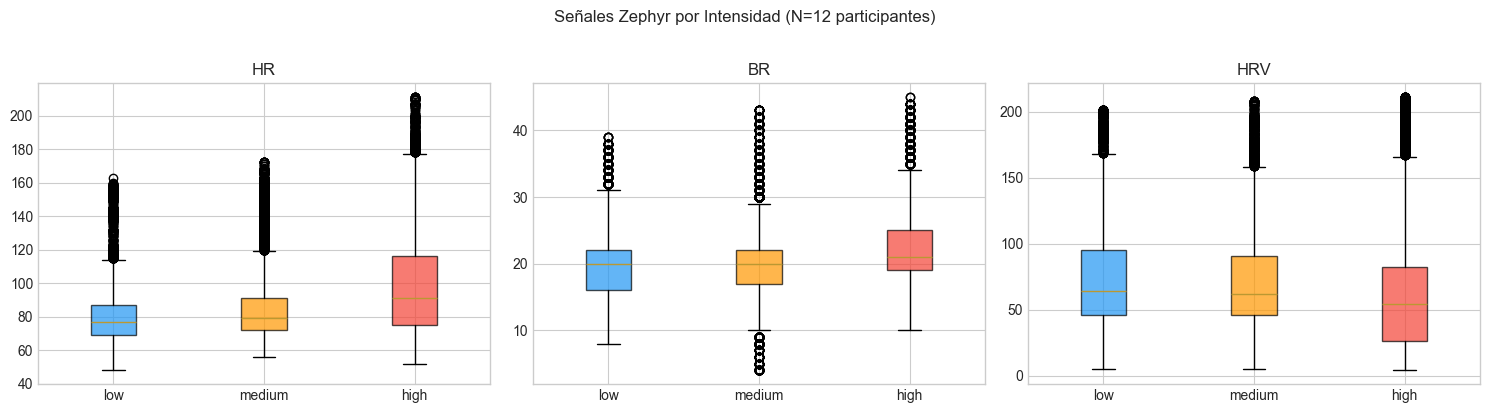


Registros no confiables:
  is_hr_unreliable: 2841 (6.19%)
  is_br_unreliable: 300 (0.65%)
  is_hrv_unreliable: 0 (0.00%)


In [12]:
if df_chest is not None:
    cols_plot = [c for c in ['hr', 'br', 'hrv'] if c in df_chest.columns]
    if cols_plot:
        fig = utils.plot_boxplots_sensor(
            df_chest, cols_plot,
            titulo='Señales Zephyr por Intensidad (N=12 participantes)'
        )
        plt.show()

    # Verificar registros no confiables
    print('\nRegistros no confiables:')
    for col in ['is_hr_unreliable', 'is_br_unreliable', 'is_hrv_unreliable']:
        if col in df_chest.columns:
            n = (df_chest[col] == 1).sum()
            pct = n / len(df_chest) * 100
            print(f'  {col}: {n} ({pct:.2f}%)')

---
## Celda 9 — Señales de muñeca: Empatica E4

El loader devuelve un dict con todas las señales de la Empatica E4:
- `hr`: frecuencia cardíaca
- `eda`: actividad electrodérmica (Galvanic Skin Response)
- `bvp`: blood volume pulse
- `temp`: temperatura cutánea
- `ibi`: inter-beat interval
- `acc`: acelerómetro

In [13]:
wrist_data = dataset['wrist']

for nombre, df in wrist_data.items():
    if df is None:
        print(f'  wrist_{nombre}: no disponible')
        continue
    # Columna de señal: primera que no sea metadato
    meta_cols = {'timestamp', 'sesion', 'participante', 'intensidad', 'intensidad_num', 'datetime'}
    col_val = next((c for c in df.columns if c not in meta_cols), None)
    if col_val:
        print(f'\nwrist_{nombre} ({col_val}):')
        print(f'  Registros: {len(df):,} | Participantes: {df["participante"].nunique()}')
        print(f'  Global: media={df[col_val].mean():.3f}, std={df[col_val].std():.3f}')


wrist_hr (hr):
  Registros: 43,608 | Participantes: 12
  Global: media=85.042, std=20.581

wrist_eda (eda):
  Registros: 174,423 | Participantes: 12
  Global: media=1.328, std=2.137

wrist_bvp (bvp):
  Registros: 2,790,818 | Participantes: 12
  Global: media=-0.004, std=56.148

wrist_temp (temp):


  Registros: 174,161 | Participantes: 12
  Global: media=33.458, std=2.086

wrist_acc (ax):
  Registros: 1,395,411 | Participantes: 12
  Global: media=-0.207, std=0.550

wrist_ibi (duration):
  Registros: 23,495 | Participantes: 12
  Global: media=741.213, std=165.197


EDA por intensidad:


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,57885.0,1.8850,2.6268,0.0,0.2947,0.5679,2.5016,14.3016
low,52212.0,0.7585,1.1296,0.0,0.1384,0.3165,0.8194,6.7658
medium,64326.0,1.2883,2.1428,0.0,0.1794,0.3882,1.0711,14.4891


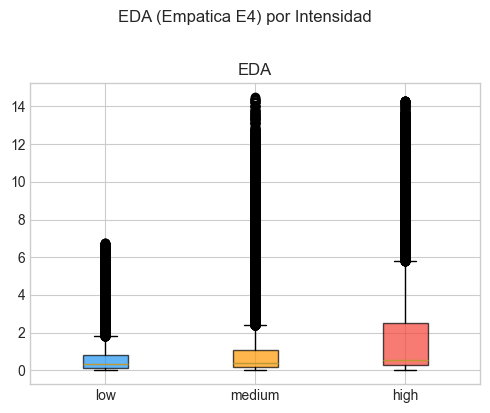

In [14]:
# Boxplot EDA por intensidad
if df_wrist_eda is not None and 'eda' in df_wrist_eda.columns:
    print('EDA por intensidad:')
    display(df_wrist_eda.groupby('intensidad')['eda'].describe().round(4))

    fig = utils.plot_boxplots_sensor(
        df_wrist_eda, ['eda'],
        titulo='EDA (Empatica E4) por Intensidad'
    )
    plt.show()

---
## Celda 10 — EEG (Muse): bandas de frecuencia

El loader carga los 5 archivos de bandas EEG absolutas del Muse:
`alpha`, `beta`, `delta`, `gamma`, `theta`.

Canales: **TP9** (temporal posterior izq.) · **AF7** (frontal izq.) · **AF8** (frontal der.) · **TP10** (temporal posterior der.)

La librería añade una columna `promedio_canales` con la media de los 4 canales.

In [15]:
for banda, df in eeg_data.items():
    if df is None:
        print(f'  {banda}: no disponible')
        continue
    canales_ok = [c for c in CANALES_EEG if c in df.columns]
    print(f'\n{banda.upper()}: {len(df):,} registros | canales: {canales_ok}')
    if 'promedio_canales' in df.columns:
        display(df.groupby('intensidad')['promedio_canales'].describe().round(4))


ALPHA: 413,176 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134555.0,0.5822,0.2866,-0.1601,0.3879,0.5512,0.7464,2.5169
low,127266.0,0.5446,0.2596,-0.1669,0.3796,0.5286,0.7116,1.4382
medium,151355.0,-inf,NaN,-inf,0.4049,0.5529,0.7323,2.7972



BETA: 413,130 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134552.0,0.4158,0.2396,-0.2031,0.2457,0.3865,0.5768,1.9357
low,127216.0,0.3650,0.1830,-0.0626,0.2495,0.3530,0.4577,1.1179
medium,151362.0,-inf,NaN,-inf,0.2812,0.3941,0.5500,2.1963



DELTA: 413,058 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134526.0,0.6334,0.4391,-0.5886,0.3114,0.6005,0.8953,3.4106
low,127192.0,0.5562,0.3929,-0.6138,0.2525,0.5538,0.8485,1.5858
medium,151340.0,-inf,NaN,-inf,0.2811,0.5474,0.8525,3.6396



GAMMA: 412,833 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134508.0,0.1255,0.2880,-0.6461,-0.0778,0.0738,0.3126,1.4260
low,127165.0,0.1377,0.1643,-0.4068,0.0143,0.1226,0.2437,0.9033
medium,151160.0,-inf,NaN,-inf,0.0060,0.1322,0.3375,1.6037



THETA: 413,029 registros | canales: ['TP9', 'AF7', 'AF8', 'TP10']


,count,mean,std,min,25%,50%,75%,max
intensidad,,,,,,,,
high,134554.0,0.441,0.3562,-0.5056,0.1818,0.3914,0.6629,2.3934
low,127144.0,0.444,0.3572,-0.5045,0.1791,0.3911,0.6922,1.4638
medium,151331.0,-inf,NaN,-inf,0.1874,0.3723,0.6175,2.6882


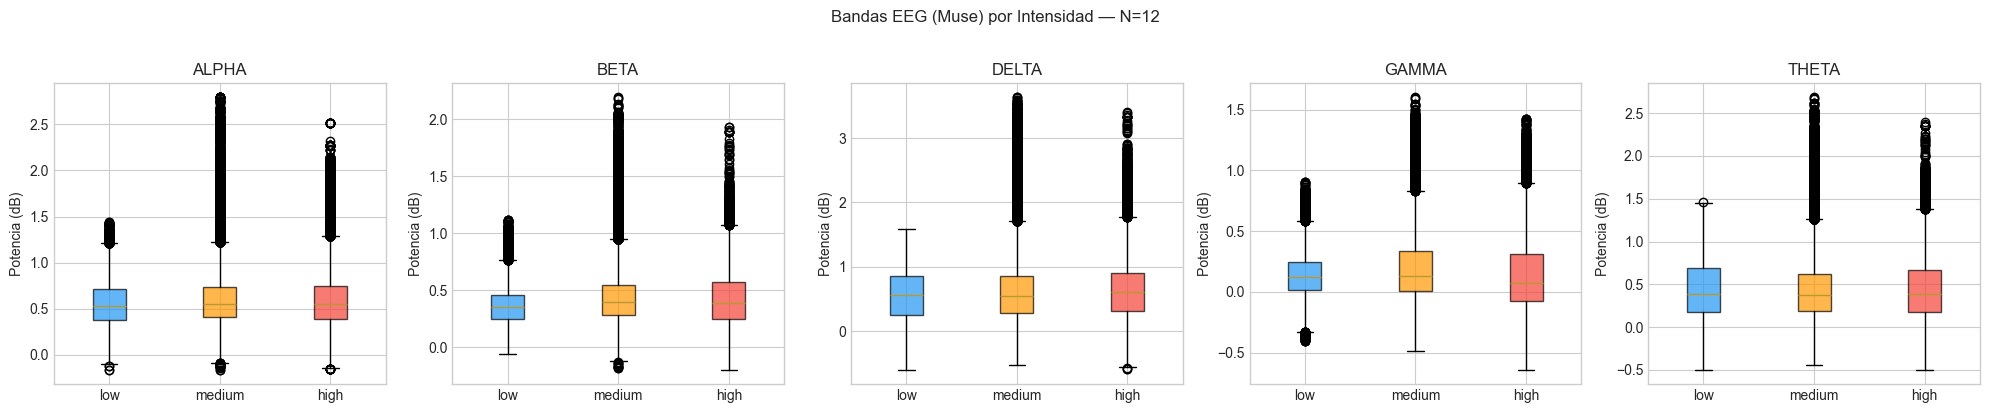

In [16]:
# Visualizar potencia media de cada banda por intensidad
bandas_ok = [b for b, df in eeg_data.items() if df is not None and 'promedio_canales' in df.columns]

if bandas_ok:
    fig, axes = plt.subplots(1, len(bandas_ok), figsize=(4 * len(bandas_ok), 4))
    if len(bandas_ok) == 1:
        axes = [axes]

    colores = {'low': '#2196F3', 'medium': '#FF9800', 'high': '#F44336'}
    for ax, banda in zip(axes, bandas_ok):
        df = eeg_data[banda]
        datos = [df[df['intensidad'] == i]['promedio_canales'].dropna()
                 for i in ['low', 'medium', 'high']]
        bp = ax.boxplot(datos, patch_artist=True, labels=['low', 'medium', 'high'])
        for patch, c in zip(bp['boxes'], colores.values()):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_title(banda.upper())
        ax.set_ylabel('Potencia (dB)')

    plt.suptitle('Bandas EEG (Muse) por Intensidad — N=12', y=1.02)
    plt.tight_layout()
    plt.show()

---
## Celda 11 — PPG auricular: Nokia eSense

El Nokia eSense mide PPG (photoplethysmography) en el canal auditivo.
Se recogen señales para el oído izquierdo y el derecho.

In [17]:
ear_data = dataset['ear']

for nombre, df in ear_data.items():
    if df is None:
        print(f'  ear_{nombre}: no disponible')
        continue
    print(f'\nPPG {nombre}: {len(df):,} registros | Participantes: {df["participante"].nunique()}')
    cols_datos = [c for c in ['green', 'ir', 'red'] if c in df.columns]
    if cols_datos:
        display(df.groupby('intensidad')[cols_datos].describe().round(2))


PPG left: 3,932,967 registros | Participantes: 12


green                                                          \
                count      mean       std      min      25%      50%      75%   
intensidad                                                                      
high        1194703.0  55604.31  27173.10    875.0  36279.0  45473.0  84582.0   
low         1211537.0  55876.03  28625.12   9013.0  31083.0  51991.0  86462.0   
medium      1526727.0  61850.08  25744.47  26479.0  42553.0  55506.0  73864.0   

                             ir                                          \
                 max      count       mean       std      min       25%   
intensidad                                                                
high        128791.0  1194703.0  286802.47  41702.20   1406.0  276494.0   
low         110839.0  1211537.0  299293.47  32617.35  57805.0  286205.0   
medium      122774.0  1526727.0  285257.58  49529.71  47381.0  254281.0   

                                                red                       \
                 50%       75%       max      count       mean       std   
intensidad                                                                 
high        285222.0  323137.5  387717.0  1194703.0  291486.45  92944.33   
low         307068.0  323233.0  354027.0  1211537.0  306007.99  85324.97   
medium      284200.0  330691.0  382741.0  1526727.0  297395.49  83847.56   

                                                             
                min       25%       50%       75%       max  
intensidad                                                   
high         1881.0  207385.0  296935.0  372984.0  479585.0  
low         57798.0  210010.0  317305.0  394190.0  431927.0  
medium      57838.0  202807.0  304582.0  367269.5  430256.0


PPG right: 3,933,102 registros | Participantes: 12


green                                                         \
                count      mean       std     min      25%      50%      75%   
intensidad                                                                     
high        1194830.0  37969.44  20161.67  1955.0  23145.0  32506.0  47519.0   
low         1211378.0  39400.01  12382.70  2448.0  32642.0  36526.0  41989.0   
medium      1526894.0  40728.84  17677.26  4418.0  25465.0  38293.0  51073.0   

                             ir                                         \
                 max      count       mean       std     min       25%   
intensidad                                                               
high        109187.0  1194830.0  208530.08  48410.65  2435.0  174160.0   
low         118510.0  1211378.0  220211.27  38931.90  3228.0  197598.0   
medium      144116.0  1526894.0  227418.99  40262.83  6176.0  196909.0   

                                                 red                       \
                 50%        75%       max      count       mean       std   
intensidad                                                                  
high        208322.0  233457.75  338392.0  1194830.0  207404.23  85296.76   
low         217186.0  257557.00  323388.0  1211378.0  217358.38  55519.81   
medium      229579.5  256974.00  355920.0  1526894.0  231277.11  74776.11   

                                                              
                min        25%       50%       75%       max  
intensidad                                                    
high         4634.0  137075.00  198043.0  269274.0  447258.0  
low          5859.0  167389.00  210874.0  265692.0  498447.0  
medium      12020.0  152075.25  217231.0  278021.0  461417.0

---
## Celda 12 — Tareas Cognitivas: N-Back y CRT

### N-Back
Tarea de memoria de trabajo. Se registra si la respuesta fue correcta (`isCorrectResponse`) y el tiempo de reacción.

### CRT (Choice Reaction Time)
Tarea de tiempo de reacción. Mide la velocidad de respuesta cognitiva.

Ambas tareas se realizan en los 3 momentos de medición (M1, M2, M3).

In [18]:
# N-Back
if df_nback is not None:
    print(f'N-Back: {len(df_nback):,} trials | {df_nback["participante"].nunique()} participantes')
    print(f'Columnas: {list(df_nback.columns)}')

    if 'isCorrectResponse' in df_nback.columns and 'fase' in df_nback.columns:
        resumen_nback = df_nback.groupby(['intensidad', 'fase']).agg(
            accuracy=('isCorrectResponse',
                      lambda x: pd.to_numeric(x, errors='coerce').mean() * 100),
            n_trials=('isCorrectResponse', 'count')
        ).round(2)
        print('\nAccuracy N-Back por intensidad y fase:')
        display(resumen_nback)

N-Back: 2,160 trials | 12 participantes
Columnas: ['trialStartTime', 'trialEndTime', 'stimulus', 'correctResponse', 'participantResponse', 'isCorrectResponse', 'responseTime', 'thisBlockTrialNumber', 'measurementBlock', 'participante', 'sesion', 'intensidad', 'intensidad_num']


In [19]:
# CRT
if df_crt is not None:
    print(f'CRT: {len(df_crt):,} trials | {df_crt["participante"].nunique()} participantes')
    print(f'Columnas: {list(df_crt.columns)}')

    # Encontrar columna de RT (tiempo de respuesta)
    rt_col = next(
        (c for c in df_crt.columns
         if 'time' in c.lower() and 'response' in c.lower()
         and pd.to_numeric(df_crt[c], errors='coerce').notna().any()),
        None
    )
    print(f'\nColumna RT detectada: {rt_col}')

    if rt_col and 'fase' in df_crt.columns:
        resumen_crt = df_crt.groupby(['intensidad', 'fase']).agg(
            rt_medio=(rt_col,
                      lambda x: pd.to_numeric(x, errors='coerce').mean()),
            n_trials=(rt_col, 'count')
        ).round(3)
        print('\nRT medio CRT por intensidad y fase:')
        display(resumen_crt)

CRT: 3,888 trials | 12 participantes
Columnas: ['trialStartTime', 'stimulusStartTime', 'stimulusCoords', 'correctResponse', 'participantResponse', 'isCorrectResponse', 'responseTime', 'thisBlockTrialNumber', 'measurementBlock', 'participante', 'sesion', 'intensidad', 'intensidad_num']

Columna RT detectada: responseTime


---
## Celda 13 — `FatigueSetProcessor`: segmentación temporal por fase

Las señales continuas (chest, EDA, EEG) no tienen etiqueta de fase — se graban
durante toda la sesión. Para asignar cada segmento a M1/M2/M3 se usa la
**aproximación de tercios temporales**:

```
segmentar_por_fase(df, fase_num=0)  → primer tercio  → M1
segmentar_por_fase(df, fase_num=1)  → segundo tercio → M2
segmentar_por_fase(df, fase_num=2)  → tercer tercio  → M3
```

> **Nota:** Para mayor precisión se pueden usar los timestamps de `exp_markers.csv`.

In [20]:
from fatigueset.processor import FatigueSetProcessor

# Ejemplo de segmentación manual
if df_chest is not None:
    # Seleccionar datos de P01, S01
    df_p01_s01 = df_chest[
        (df_chest['participante'] == '01') &
        (df_chest['sesion'] == '01')
    ].reset_index(drop=True)

    print(f'P01/S01 chest total: {len(df_p01_s01)} registros')

    for fase_num, fase_nombre in FASES_MEDICION.items():
        seg = FatigueSetProcessor.segmentar_por_fase(df_p01_s01, fase_num)
        metricas = FatigueSetProcessor.metricas_segmento(
            seg, ['hr', 'br', 'hrv']
        )
        print(f'\n  {fase_nombre}:')
        for k, v in metricas.items():
            print(f'    {k}: {v:.2f}' if pd.notna(v) else f'    {k}: NaN')

P01/S01 chest total: 1578 registros

  M1_baseline:
    hr_media: 60.13
    hr_std: 9.98
    br_media: 16.53
    br_std: 2.09
    hrv_media: 64.76
    hrv_std: 25.16

  M2_post_ejercicio:
    hr_media: 65.28
    hr_std: 14.94
    br_media: 18.98
    br_std: 4.16
    hrv_media: 142.94
    hrv_std: 49.67

  M3_post_fatiga_mental:
    hr_media: 58.91
    hr_std: 3.44
    br_media: 15.52
    br_std: 2.14
    hrv_media: 57.79
    hrv_std: 5.55


---
## Celda 14 — `construir_dataset_ml()`: dataset ML agregado (108 filas)

La función construye el dataset principal para ML con granularidad:

**12 participantes × 3 sesiones × 3 fases = 108 filas**

Para cada fila combina:
1. Scores de fatiga subjetiva (VAS)
2. Métricas de señales fisiológicas (HR, BR, HRV, EDA)
3. Métricas EEG por banda
4. Rendimiento cognitivo (N-Back accuracy + RT, CRT RT)

In [21]:
df_ml = processor.construir_dataset_ml(
    df_fatiga    = df_fatiga,
    df_chest     = df_chest,
    df_wrist_eda = df_wrist_eda,
    eeg_data     = eeg_data,
    df_nback     = df_nback,
    df_crt       = df_crt,
)

print(f'✓ Dataset ML: {len(df_ml)} filas × {len(df_ml.columns)} columnas')
print(f'  Columnas: {list(df_ml.columns)}')
print()
display(df_ml.head(9))

✓ Dataset ML: 108 filas × 19 columnas
  Columnas: ['participante', 'sesion', 'intensidad', 'intensidad_num', 'fase', 'fase_num', 'fatiga_fisica', 'fatiga_mental', 'hr_media', 'hr_std', 'br_media', 'br_std', 'hrv_media', 'hrv_std', 'eda_media', 'eda_std', 'eeg_alpha_media', 'eeg_beta_media', 'eeg_theta_media']



,participante,sesion,intensidad,intensidad_num,fase,fase_num,fatiga_fisica,fatiga_mental,hr_media,hr_std,br_media,br_std,hrv_media,hrv_std,eda_media,eda_std,eeg_alpha_media,eeg_beta_media,eeg_theta_media
0,01,01,low,1,M1_baseline,0,14.444444,14.166667,60.125475,9.977663,16.532319,2.092595,64.756654,25.157517,0.090051,0.011899,0.372231,0.373758,0.148017
1,01,01,low,1,M2_post_ejercicio,1,24.027778,11.250000,65.277567,14.944180,18.984791,4.162389,142.944867,49.666265,0.095337,0.003648,0.466424,0.418221,0.313745
2,01,01,low,1,M3_post_fatiga_mental,2,20.000000,45.833333,58.906844,3.444923,15.524715,2.139505,57.788973,5.546269,0.104860,0.005379,0.342213,0.446965,0.087872
3,01,02,medium,2,M1_baseline,0,15.277778,33.472222,65.387025,10.415369,11.682327,4.381190,79.362416,21.274171,0.122299,0.017222,0.459924,0.574508,0.204564
4,01,02,medium,2,M2_post_ejercicio,1,59.166667,48.333333,91.997763,22.026126,21.322148,2.961491,122.304251,42.425948,1.512250,0.993087,0.681291,0.621546,0.586466
5,01,02,medium,2,M3_post_fatiga_mental,2,31.527778,34.027778,68.961969,3.067387,15.935123,1.255587,44.252796,7.155298,0.182441,0.086829,0.356430,0.740107,0.026915
6,01,03,high,3,M1_baseline,0,10.000000,4.027778,66.698413,13.590010,15.120181,1.353976,74.074830,27.833291,0.173108,0.029926,0.438943,0.665357,0.215749
7,01,03,high,3,M2_post_ejercicio,1,77.222222,37.500000,100.433107,22.632954,24.047619,5.121257,112.195011,55.248143,1.197675,0.676726,0.478708,0.431169,0.375164
8,01,03,high,3,M3_post_fatiga_mental,2,48.333333,35.833333,75.925339,3.039624,16.520362,1.682454,33.866516,8.071832,0.205446,0.077204,0.375333,0.753410,0.053149


In [22]:
# Estadísticas descriptivas del dataset ML
display(df_ml.describe().round(3))

,intensidad_num,fase_num,fatiga_fisica,fatiga_mental,hr_media,hr_std,br_media,br_std,hrv_media,hrv_std,eda_media,eda_std,eeg_alpha_media,eeg_beta_media,eeg_theta_media
count,108.00,108.00,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,105.000,105.000,105.000
mean,2.00,1.00,23.529,26.411,87.875,11.357,20.806,2.794,69.464,19.737,1.273,0.474,-inf,-inf,-inf
std,0.82,0.82,18.809,19.819,20.157,8.072,4.498,1.590,31.155,14.958,1.789,0.885,NaN,NaN,NaN
min,1.00,0.00,0.000,0.000,58.907,2.002,11.682,0.529,11.276,0.430,0.076,0.003,-inf,-inf,-inf
25%,1.00,0.00,9.028,11.667,73.804,4.960,17.875,1.578,49.336,7.861,0.194,0.024,0.466,0.300,0.299
50%,2.00,1.00,20.069,23.056,81.871,9.430,20.328,2.396,64.569,15.014,0.477,0.096,0.541,0.383,0.412
75%,3.00,2.00,34.167,36.076,97.107,15.014,23.397,3.730,86.265,25.288,1.406,0.441,0.686,0.471,0.554
max,3.00,2.00,77.222,77.222,162.281,37.052,33.430,7.853,189.376,73.667,7.681,4.695,0.998,0.753,1.054


In [23]:
# Guardar el dataset ML (mismo directorio que el notebook)
output_path = Path('fatigueset_aggregated_features.csv')
df_ml.to_csv(output_path, index=False)
print(f'✓ Guardado: {output_path.resolve()}')

✓ Guardado: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\Jupyters\fatigueset_aggregated_features.csv


---
## Celda 15 — `FeatureExtractor`: features avanzadas

La clase `FeatureExtractor` extrae features más ricas que las simples media/std
del procesador. Incluye:

| Método | Features |
|---|---|
| `features_serie(serie)` | media, std, min, max, rango, CV, percentiles |
| `features_hrv(df_rr)` | RMSSD, SDNN, pNN50, media RR |
| `features_eda(df_eda)` | media/std/rango, pendiente lineal, nº picos SCR |
| `features_eeg_banda(df, banda)` | stats por canal + promedio global |
| `features_cognitivas(df_nback, df_crt)` | accuracy, nº errores, RT media/std |

In [24]:
extractor = FeatureExtractor(percentiles=[25, 50, 75])

# --- Features avanzadas de EDA para P01/S01 ---
if df_wrist_eda is not None and 'eda' in df_wrist_eda.columns:
    df_eda_p01 = df_wrist_eda[
        (df_wrist_eda['participante'] == '01') &
        (df_wrist_eda['sesion'] == '01')
    ]

    for fase_num, fase_nombre in FASES_MEDICION.items():
        seg = FatigueSetProcessor.segmentar_por_fase(
            df_eda_p01.reset_index(drop=True), fase_num
        )
        feats_eda = extractor.features_eda(seg, col_eda='eda')
        print(f'\nEDA — P01/S01 / {fase_nombre}:')
        for k, v in feats_eda.items():
            print(f'  {k:25s}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')


EDA — P01/S01 / M1_baseline:
  eda_media                : 0.0901
  eda_std                  : 0.0119
  eda_min                  : 0.0192
  eda_max                  : 0.1409
  eda_rango                : 0.1217
  eda_cv                   : 0.1321
  eda_p25                  : 0.0794
  eda_p50                  : 0.0948
  eda_p75                  : 0.0999
  eda_pendiente            : 0.0000
  eda_n_picos_scr: 131

EDA — P01/S01 / M2_post_ejercicio:
  eda_media                : 0.0953
  eda_std                  : 0.0036
  eda_min                  : 0.0705
  eda_max                  : 0.1179
  eda_rango                : 0.0474
  eda_cv                   : 0.0383
  eda_p25                  : 0.0923
  eda_p50                  : 0.0948
  eda_p75                  : 0.0974
  eda_pendiente            : 0.0000
  eda_n_picos_scr: 196

EDA — P01/S01 / M3_post_fatiga_mental:
  eda_media                : 0.1049
  eda_std                  : 0.0054
  eda_min                  : 0.0308
  eda_max           

In [25]:
# --- Features HRV desde intervalos RR ---
df_rr = dataset.get('chest')  # chest_rr_interval.csv si se cargó directamente

# Intentar cargar chest_rr_interval.csv explícitamente
df_rr_raw = fs_loader.cargar_todos('chest_rr_interval.csv')

if df_rr_raw is not None:
    # Detectar columna RR
    col_rr = next((c for c in df_rr_raw.columns if 'rr' in c.lower()), None)
    print(f'Columna RR: {col_rr}')

    if col_rr:
        df_rr_p01 = df_rr_raw[
            (df_rr_raw['participante'] == '01') &
            (df_rr_raw['sesion'] == '01')
        ]
        for fase_num, fase_nombre in FASES_MEDICION.items():
            seg = FatigueSetProcessor.segmentar_por_fase(
                df_rr_p01.reset_index(drop=True), fase_num
            )
            feats_hrv = extractor.features_hrv(seg, col_rr=col_rr)
            print(f'\nHRV — P01/S01 / {fase_nombre}:')
            for k, v in feats_hrv.items():
                print(f'  {k}: {v:.4f}')
else:
    print('chest_rr_interval.csv no disponible en el dataset.')

Columna RR: None

In [26]:
# --- Features EEG por canal para una banda ---
if 'alpha' in eeg_data and eeg_data['alpha'] is not None:
    df_alpha_p01 = eeg_data['alpha'][
        (eeg_data['alpha']['participante'] == '01') &
        (eeg_data['alpha']['sesion'] == '01')
    ]

    seg = FatigueSetProcessor.segmentar_por_fase(
        df_alpha_p01.reset_index(drop=True), fase_num=0  # M1
    )
    feats_eeg = extractor.features_eeg_banda(seg, banda='alpha')

    print('EEG Alpha — P01/S01/M1 — features avanzadas:')
    for k, v in feats_eeg.items():
        print(f'  {k:35s}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

EEG Alpha — P01/S01/M1 — features avanzadas:
  eeg_alpha_TP9_media                : 0.6014
  eeg_alpha_TP9_std                  : 0.3921
  eeg_alpha_TP9_min                  : -0.5600
  eeg_alpha_TP9_max                  : 1.9856
  eeg_alpha_TP9_rango                : 2.5457
  eeg_alpha_TP9_cv                   : 0.6521
  eeg_alpha_TP9_p25                  : 0.3762
  eeg_alpha_TP9_p50                  : 0.5243
  eeg_alpha_TP9_p75                  : 0.7265
  eeg_alpha_AF7_media                : 0.2882
  eeg_alpha_AF7_std                  : 0.2836
  eeg_alpha_AF7_min                  : -0.5935
  eeg_alpha_AF7_max                  : 1.2209
  eeg_alpha_AF7_rango                : 1.8143
  eeg_alpha_AF7_cv                   : 0.9838
  eeg_alpha_AF7_p25                  : 0.0814
  eeg_alpha_AF7_p50                  : 0.2584
  eeg_alpha_AF7_p75                  : 0.4577
  eeg_alpha_AF8_media                : 0.1574
  eeg_alpha_AF8_std                  : 0.2257
  eeg_alpha_AF8_min              

In [27]:
# --- Features cognitivas combinadas N-Back + CRT ---
if df_nback is not None and df_crt is not None:
    # Asegurarse de que existe la columna 'fase' (requiere measurementNumber en el CSV)
    if 'fase' not in df_nback.columns:
        print('⚠ df_nback no tiene columna "fase" — exp_nback.csv no contiene measurementNumber')
        print(f'  Columnas disponibles: {list(df_nback.columns)}')
    else:
        fase_sel = 'M2_post_ejercicio'
        df_nb_p01 = df_nback[
            (df_nback['participante'] == '01') &
            (df_nback['sesion'] == '01') &
            (df_nback['fase'] == fase_sel)
        ]

        crt_fase_col = 'fase' if 'fase' in df_crt.columns else None
        df_crt_p01 = df_crt[
            (df_crt['participante'] == '01') &
            (df_crt['sesion'] == '01') &
            (df_crt[crt_fase_col] == fase_sel if crt_fase_col else True)
        ] if crt_fase_col else df_crt[
            (df_crt['participante'] == '01') &
            (df_crt['sesion'] == '01')
        ]

        feats_cog = extractor.features_cognitivas(df_nb_p01, df_crt_p01)
        print(f'Features cognitivas — P01/S01/{fase_sel}:')
        for k, v in feats_cog.items():
            print(f'  {k}: {v}')

⚠ df_nback no tiene columna "fase" — exp_nback.csv no contiene measurementNumber
  Columnas disponibles: ['trialStartTime', 'trialEndTime', 'stimulus', 'correctResponse', 'participantResponse', 'isCorrectResponse', 'responseTime', 'thisBlockTrialNumber', 'measurementBlock', 'participante', 'sesion', 'intensidad', 'intensidad_num']


---
## Celda 16 — Correlaciones y análisis del dataset ML

Usamos `utils.plot_correlacion()` y `utils.top_correlaciones()` para identificar
qué señales fisiológicas predicen mejor la fatiga mental y física.

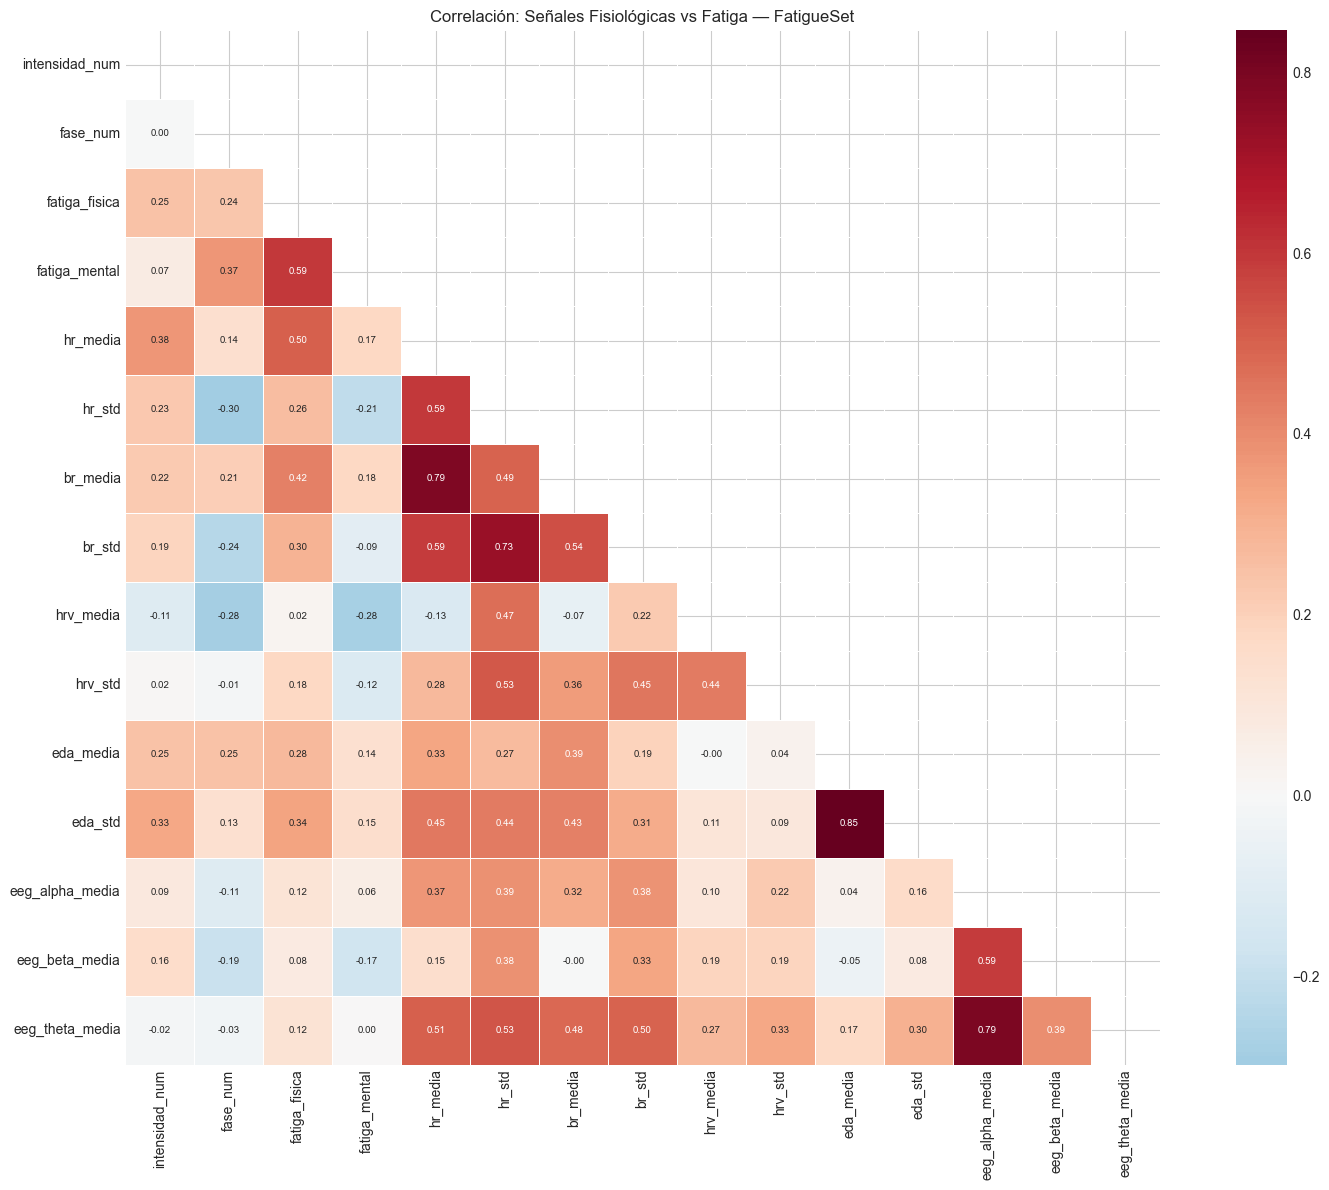

In [28]:
if df_ml is not None and len(df_ml.select_dtypes(include='number').columns) > 2:
    fig = utils.plot_correlacion(
        df_ml,
        titulo='Correlación: Señales Fisiológicas vs Fatiga — FatigueSet'
    )
    plt.show()

In [29]:
# Top features correlacionadas con fatiga mental
try:
    top_mental = utils.top_correlaciones(df_ml, target='fatiga_mental', n=10)
    print('Top 10 features correlacionadas con fatiga_mental:')
    display(top_mental.to_frame('correlación'))
except ValueError as e:
    print(f'⚠ {e}')

try:
    top_fisica = utils.top_correlaciones(df_ml, target='fatiga_fisica', n=10)
    print('\nTop 10 features correlacionadas con fatiga_fisica:')
    display(top_fisica.to_frame('correlación'))
except ValueError as e:
    print(f'⚠ {e}')

Top 10 features correlacionadas con fatiga_mental:


,correlación
fase_num,0.373
hrv_media,-0.281
hr_std,-0.211
br_media,0.179
hr_media,0.174
eeg_beta_media,-0.170
eda_std,0.149
eda_media,0.138
hrv_std,-0.123
br_std,-0.086



Top 10 features correlacionadas con fatiga_fisica:


,correlación
fatiga_mental,0.595
hr_media,0.503
br_media,0.424
eda_std,0.338
br_std,0.297
eda_media,0.278
hr_std,0.264
intensidad_num,0.249
fase_num,0.238
hrv_std,0.179


---
## Celda 17 — Análisis de fatigabilidad por participante

Visualización detallada de cómo varía la fatigabilidad según la intensidad
de la sesión para cada participante.

Scores absolutos medios por intensidad:


,fisica_M1,fisica_M2,fisica_M3,mental_M1,mental_M2,mental_M3
intensidad,,,,,,
high,13.58,45.22,29.36,15.97,26.49,37.74
low,12.91,18.87,22.15,15.00,19.49,35.25
medium,16.31,29.37,23.99,24.11,27.49,36.15


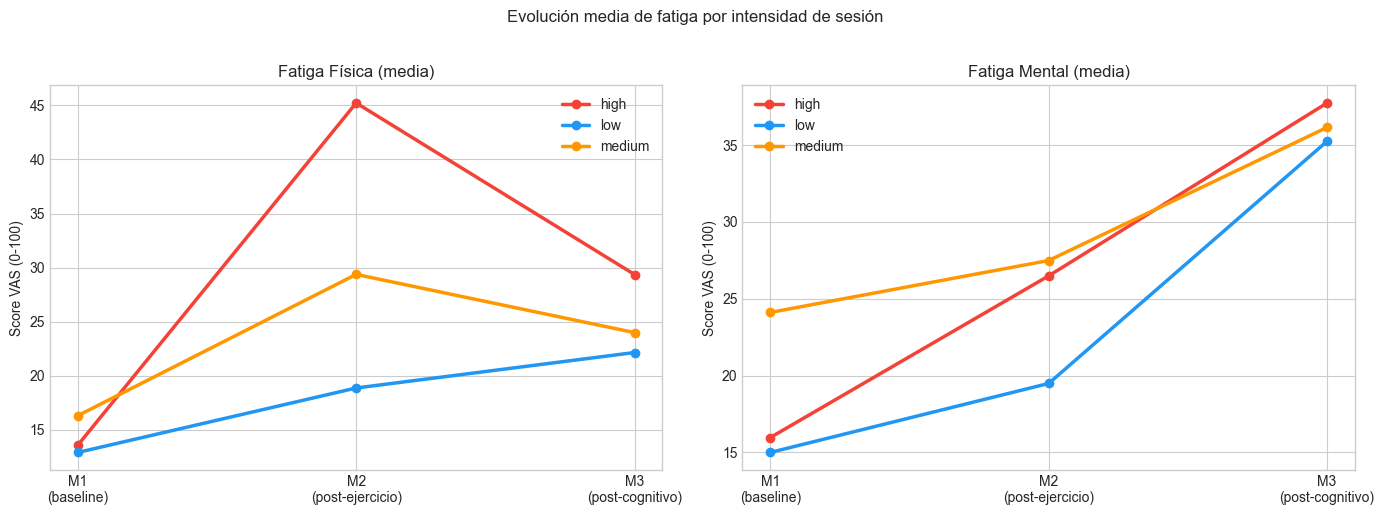

In [30]:
if df_fatiga is not None:
    # Pivot para comparar scores absolutos en M1/M2/M3 por intensidad
    df_scores = df_fatigabilidad.groupby('intensidad')[
        ['fisica_M1', 'fisica_M2', 'fisica_M3',
         'mental_M1', 'mental_M2', 'mental_M3']
    ].mean().round(2)

    print('Scores absolutos medios por intensidad:')
    display(df_scores)

    # Gráfico de líneas: evolución media por intensidad
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colores = {'low': '#2196F3', 'medium': '#FF9800', 'high': '#F44336'}
    fases_labels = ['M1\n(baseline)', 'M2\n(post-ejercicio)', 'M3\n(post-cognitivo)']

    for intensidad, row in df_scores.iterrows():
        color = colores.get(intensidad, 'gray')
        axes[0].plot(
            [0, 1, 2],
            [row['fisica_M1'], row['fisica_M2'], row['fisica_M3']],
            marker='o', linewidth=2.5, color=color, label=intensidad
        )
        axes[1].plot(
            [0, 1, 2],
            [row['mental_M1'], row['mental_M2'], row['mental_M3']],
            marker='o', linewidth=2.5, color=color, label=intensidad
        )

    for ax, titulo in zip(axes, ['Fatiga Física (media)', 'Fatiga Mental (media)']):
        ax.set_title(titulo)
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(fases_labels)
        ax.set_ylabel('Score VAS (0-100)')
        ax.legend()

    plt.suptitle('Evolución media de fatiga por intensidad de sesión', y=1.02)
    plt.tight_layout()
    plt.show()

---
## Celda 18 — Resumen: API pública de la librería

```python
from fatigueset import (
    FatigueSetLoader,     # Carga de datos
    FatigueSetProcessor,  # Procesado y construcción ML
    FatigueSetValidator,  # Validación de integridad
    FeatureExtractor,     # Features avanzadas
    utils,                # Visualizaciones
)

# Pipeline completo en 4 líneas:
loader    = FatigueSetLoader('fatigueset/')
imap      = loader.construir_intensidad_map()
data      = loader.cargar_todo()
processor = FatigueSetProcessor(imap)
df_ml     = processor.construir_dataset_ml(**data_kwargs)
```

### Referencia de métodos principales

| Clase | Método | Descripción |
|---|---|---|
| `FatigueSetLoader` | `cargar_todo()` | Carga todas las señales (dict) |
| `FatigueSetLoader` | `construir_intensidad_map()` | Mapa pid×sesión→intensidad |
| `FatigueSetLoader` | `cargar_eeg(bandas=[...])` | EEG por bandas específicas |
| `FatigueSetProcessor` | `calcular_fatigabilidad(df)` | Deltas M1/M2/M3 (36 filas) |
| `FatigueSetProcessor` | `construir_dataset_ml(...)` | Dataset ML (108 filas) |
| `FatigueSetProcessor` | `segmentar_por_fase(df, n)` | Tercios temporales |
| `FeatureExtractor` | `features_hrv(df_rr)` | RMSSD, pNN50, SDNN |
| `FeatureExtractor` | `features_eda(df_eda)` | Media/std/picos SCR/pendiente |
| `FeatureExtractor` | `features_eeg_banda(df, banda)` | Stats por canal EEG |
| `FatigueSetValidator` | `imprimir_resumen()` | Reporte de calidad de datos |
| `utils` | `plot_fatiga_evolucion(df)` | Curvas M1→M2→M3 |
| `utils` | `plot_correlacion(df_ml)` | Heatmap de correlaciones |
| `utils` | `top_correlaciones(df_ml, target)` | Top N predictores |